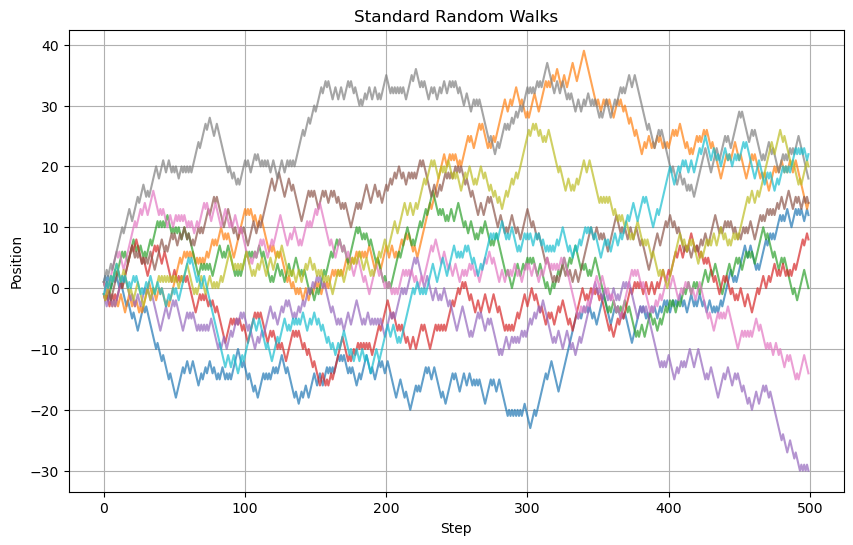

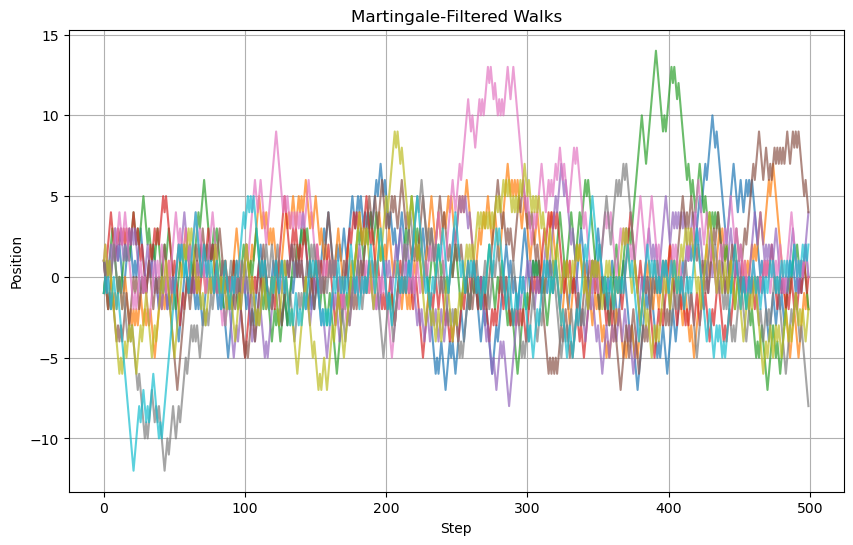

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def basic_random_walk(n_steps=100, n_walks=10):
    """Standard symmetric random walk."""
    walks = np.zeros((n_walks, n_steps))
    for i in range(n_walks):
        steps = np.random.choice([-1, 1], size=n_steps)
        walks[i] = np.cumsum(steps)
    return walks

def martingale_filtered_walk(n_steps=100, n_walks=10):
    """Random walk constrained to maintain martingale behavior over time."""
    walks = np.zeros((n_walks, n_steps))
    for i in range(n_walks):
        current_value = 0
        for t in range(n_steps):
            # Impose a simple martingale filter:
            # if drift exists, adjust probability of next step
            expected = current_value
            if current_value > 0:
                p_up = 0.4  # slightly more likely to go down
            elif current_value < 0:
                p_up = 0.6  # more likely to go up
            else:
                p_up = 0.5
            step = np.random.choice([-1, 1], p=[1 - p_up, p_up])
            current_value += step
            walks[i, t] = current_value
    return walks

# Plotting both
def plot_walks(walks, title):
    plt.figure(figsize=(10, 6))
    for i in range(walks.shape[0]):
        plt.plot(walks[i], alpha=0.7)
    plt.title(title)
    plt.xlabel('Step')
    plt.ylabel('Position')
    plt.grid(True)
    plt.show()

# Run simulations
n_steps = 500
n_walks = 10

unfiltered_walks = basic_random_walk(n_steps, n_walks)
filtered_walks = martingale_filtered_walk(n_steps, n_walks)

# Visualize
plot_walks(unfiltered_walks, "Standard Random Walks")
plot_walks(filtered_walks, "Martingale-Filtered Walks")